# Tutorial 18: Parallelization and Map-Reduce with LangGraph

In this tutorial we explore LangGraph's parallel execution capabilities. We start with static fan-out (multiple nodes running concurrently in the same superstep) and then build dynamic Map-Reduce workflows using the `Send` API.

## 1. LangGraph's Execution Model

LangGraph uses a **superstep** model inspired by Google's Pregel:
- All nodes scheduled in the same superstep run **concurrently**
- State updates from one superstep are applied before the next superstep begins
- You get parallelism for free by adding multiple outgoing edges from one node

The `Send` API extends this to **dynamic** parallelism where the number of parallel branches is determined at runtime, not at graph-design time.

## 2. Setup

In [1]:
import os
from typing import TypedDict, List, Annotated
import operator
from langgraph.graph import StateGraph, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0.1,
)

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 3. Static Parallelization

Adding multiple edges from one node schedules all target nodes to run in the same superstep — automatically in parallel.

In [2]:
class AnalysisState(TypedDict):
    text: str
    sentiment: str
    keywords: str
    language: str
    final_report: str


def analyse_sentiment(state: AnalysisState) -> AnalysisState:
    resp = llm.invoke([HumanMessage(content=f"What is the sentiment of this text? Reply with one word (positive/negative/neutral):\n{state['text']}" )])
    print(f"  Sentiment: {resp.content.strip()}")
    return {"sentiment": resp.content.strip()}


def extract_keywords(state: AnalysisState) -> AnalysisState:
    resp = llm.invoke([HumanMessage(content=f"Extract 5 keywords from this text as a comma-separated list:\n{state['text']}" )])
    print(f"  Keywords: {resp.content.strip()[:60]}")
    return {"keywords": resp.content.strip()}


def detect_language(state: AnalysisState) -> AnalysisState:
    resp = llm.invoke([HumanMessage(content=f"What language is this text written in? Reply with one word:\n{state['text']}" )])
    print(f"  Language: {resp.content.strip()}")
    return {"language": resp.content.strip()}


def compile_report(state: AnalysisState) -> AnalysisState:
    report = (
        f"Text Analysis Report\n"
        f"Language: {state['language']}\n"
        f"Sentiment: {state['sentiment']}\n"
        f"Keywords: {state['keywords']}"
    )
    return {"final_report": report}


workflow = StateGraph(AnalysisState)
workflow.add_node("analyse_sentiment", analyse_sentiment)
workflow.add_node("extract_keywords", extract_keywords)
workflow.add_node("detect_language", detect_language)
workflow.add_node("compile_report", compile_report)

# Fan-out: all three analysis nodes run in parallel
workflow.set_entry_point("analyse_sentiment")
workflow.set_entry_point("extract_keywords")
workflow.set_entry_point("detect_language")

# Fan-in: compile_report runs after all three complete
workflow.add_edge("analyse_sentiment", "compile_report")
workflow.add_edge("extract_keywords", "compile_report")
workflow.add_edge("detect_language", "compile_report")
workflow.add_edge("compile_report", END)

app = workflow.compile()
print("Parallel analysis graph compiled.")

Parallel analysis graph compiled.


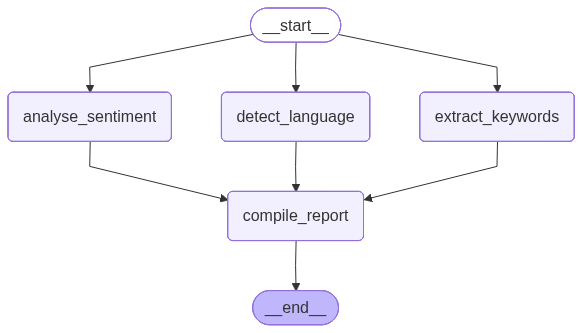

In [3]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
import time
start = time.time()
result = app.invoke({
    "text": "LangGraph is an excellent framework for building complex AI workflows with parallel execution.",
    "sentiment": "", "keywords": "", "language": "", "final_report": ""
})
elapsed = time.time() - start
print(f"\nCompleted in {elapsed:.1f}s")
print(result["final_report"])

  Sentiment: Positive
  Language: Python.
  Keywords: Here are 5 keywords extracted from the text as a comma-separ

Completed in 0.2s
Text Analysis Report
Language: Python.
Sentiment: Positive
Keywords: Here are 5 keywords extracted from the text as a comma-separated list:

LangGraph, framework, AI, workflows, parallel


## 4. The Send API — Dynamic Map-Reduce

`Send(node_name, state)` creates a dynamic invocation of a node with a specific state. A conditional edge can return a list of `Send` objects to fan out to any number of parallel workers at runtime.

**Pattern:**
1. **Map**: conditional edge returns `[Send("worker", item) for item in items]`
2. **Work**: `worker` node processes one item and appends its result to a shared list
3. **Reduce**: a final node aggregates all results

In [5]:
# State that accumulates results from parallel workers
class MapReduceState(TypedDict):
    documents: List[str]
    # Annotated with operator.add means results from parallel workers are concatenated
    summaries: Annotated[List[str], operator.add]
    final_synthesis: str


# Worker node — processes one document
class WorkerState(TypedDict):
    document: str
    summaries: Annotated[List[str], operator.add]  # appends to the shared list


def summarise_single_document(state: WorkerState) -> WorkerState:
    """Worker: summarise one document."""
    resp = llm.invoke([HumanMessage(content=f"Summarise in one sentence:\n{state['document']}" )])
    print(f"  Worker summary: {resp.content[:80]}")
    return {"summaries": [resp.content.strip()]}


def synthesise_results(state: MapReduceState) -> MapReduceState:
    """Reducer: synthesise all summaries into a final report."""
    combined = "\n".join(f"- {s}" for s in state["summaries"])
    resp = llm.invoke([HumanMessage(content=f"Synthesise these document summaries into a cohesive paragraph:\n{combined}" )])
    return {"final_synthesis": resp.content}


def fan_out_to_workers(state: MapReduceState) -> List[Send]:
    """Conditional edge: create one Send per document."""
    return [Send("summarise_document", {"document": doc, "summaries": []}) for doc in state["documents"]]


# Build Map-Reduce graph
mr_workflow = StateGraph(MapReduceState)
mr_workflow.add_node("summarise_document", summarise_single_document)
mr_workflow.add_node("synthesise_results", synthesise_results)

# The fan-out conditional edge distributes work dynamically
mr_workflow.set_conditional_entry_point(fan_out_to_workers, path_map={"summarise_document": "summarise_document"})
mr_workflow.add_edge("summarise_document", "synthesise_results")
mr_workflow.add_edge("synthesise_results", END)

mr_app = mr_workflow.compile()
print("Map-Reduce graph compiled.")

Map-Reduce graph compiled.


In [6]:
documents = [
    "LangGraph enables building stateful multi-agent workflows with explicit state management and graph-based execution.",
    "The Supervisor pattern uses a central LLM to coordinate specialised workers through tool-based delegation.",
    "Human-in-the-Loop workflows use interrupt() to pause execution and resume with Command(resume=...) after human input.",
    "The Send API allows dynamic fan-out to any number of parallel workers determined at runtime.",
]

print(f"Processing {len(documents)} documents in parallel...\n")
start = time.time()
result = mr_app.invoke({"documents": documents, "summaries": [], "final_synthesis": ""})
elapsed = time.time() - start

print(f"\nCompleted in {elapsed:.1f}s")
print("\n=== SYNTHESIS ===")
print(result["final_synthesis"])

Processing 4 documents in parallel...

  Worker summary: LangGraph is a system that allows developers to create complex, stateful workflo
  Worker summary: The Supervisor pattern utilizes a central Large Language Model (LLM) to oversee 
  Worker summary: Human-in-the-Loop workflows utilize the interrupt() function to pause execution 
  Worker summary: The Send API enables dynamic fan-out to any number of parallel workers, allowing

Completed in 0.5s

=== SYNTHESIS ===
LangGraph is a powerful system that enables developers to create intricate, stateful workflows involving multiple agents, with a strong emphasis on explicit state management and graph-based execution. This system is particularly well-suited for complex tasks that require coordination and oversight, and can be leveraged in conjunction with the Supervisor pattern. The Supervisor pattern utilizes a central Large Language Model (LLM) to direct and oversee specialized workers, delegating tasks through tools as needed. Addition

## 5. Key Pattern: Annotated Reducers

When multiple parallel workers write to the same state key, you must declare a **reducer** using `Annotated`.
- `Annotated[List[str], operator.add]` — concatenates lists from all parallel workers
- Without the annotation, LangGraph raises `InvalidUpdateError` (as seen in Tutorial 8)

In [7]:
# Summary of reducer patterns
from typing import Annotated
import operator

print("Common reducer patterns:")
print("""
  # Concatenate lists (most common for parallel workers)
  results: Annotated[List[str], operator.add]

  # Sum numbers
  total: Annotated[int, operator.add]

  # Keep last value (default, no Annotated needed)
  status: str

  # Custom reducer function
  def merge_dicts(a, b): return {**a, **b}
  metadata: Annotated[dict, merge_dicts]
""")

Common reducer patterns:

  # Concatenate lists (most common for parallel workers)
  results: Annotated[List[str], operator.add]

  # Sum numbers
  total: Annotated[int, operator.add]

  # Keep last value (default, no Annotated needed)
  status: str

  # Custom reducer function
  def merge_dicts(a, b): return {**a, **b}
  metadata: Annotated[dict, merge_dicts]



## 6. Conditional Fan-out — Returning a List of Nodes

When the routing function returns a **list** of node names, `add_conditional_edges` fans out to all of them in parallel — the same superstep behaviour as static fan-out, but now determined at runtime.

This is useful when the set of parallel branches depends on some condition evaluated at run time.

In [8]:
from typing import Annotated, List, Sequence
import operator
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class BranchState(TypedDict):
    aggregate: Annotated[List[str], operator.add]
    route: str  # 'fast', 'thorough', or 'both'

def entry_node(state: BranchState) -> dict:
    return {"aggregate": ["entry"]}

def fast_node(state: BranchState) -> dict:
    result = llm.invoke([HumanMessage(content="Name one fast fact about AI in 10 words.")]).content
    return {"aggregate": [f"[fast] {result[:80]}"]}

def thorough_node(state: BranchState) -> dict:
    result = llm.invoke([HumanMessage(content="Give a 2-sentence overview of modern AI.")]).content
    return {"aggregate": [f"[thorough] {result[:120]}"]}

def combine_node(state: BranchState) -> dict:
    print("Combined results:", state["aggregate"])
    return {}

def choose_branches(state: BranchState) -> List[str]:
    """Return a list of nodes to run in parallel based on the 'route' key."""
    if state["route"] == "fast":
        return ["fast_node"]
    elif state["route"] == "thorough":
        return ["thorough_node"]
    return ["fast_node", "thorough_node"]  # 'both' — true parallel fan-out

branch_wf = StateGraph(BranchState)
branch_wf.add_node("entry", entry_node)
branch_wf.add_node("fast_node", fast_node)
branch_wf.add_node("thorough_node", thorough_node)
branch_wf.add_node("combine", combine_node)

branch_wf.add_edge(START, "entry")
# Conditional edge returns a list → LangGraph fans out to all listed nodes in parallel
branch_wf.add_conditional_edges("entry", choose_branches, ["fast_node", "thorough_node"])
branch_wf.add_edge("fast_node", "combine")
branch_wf.add_edge("thorough_node", "combine")
branch_wf.add_edge("combine", END)

branch_app = branch_wf.compile()

import time
t0 = time.time()
r = branch_app.invoke({"aggregate": [], "route": "both"})
print(f"\n'both' route ({time.time()-t0:.1f}s): {len(r['aggregate'])} results")

r2 = branch_app.invoke({"aggregate": [], "route": "fast"})
print(f"'fast' route: {r2['aggregate']}")

Combined results: ['entry', '[fast] AI can process vast amounts of data in mere seconds.', '[thorough] Modern AI has evolved into a multifaceted field that encompasses various subfields, including machine learning, deep lea']

'both' route (0.3s): 3 results
Combined results: ['entry', '[fast] AI can process vast amounts of data in seconds instantly.']
'fast' route: ['entry', '[fast] AI can process vast amounts of data in seconds instantly.']


## 7. Stable Sorting of Parallel Outputs

By default, results from parallel branches arrive in an **arbitrary order** (whichever node finishes first). If you need a consistent, predetermined ordering — for example to rank results by confidence score — use a **custom reducer**.

The pattern:
1. Each parallel worker writes `{"value": ..., "score": ...}` to a `fanout_values` list
2. A `reduce_fanouts` reducer accumulates these during the superstep
3. The sink node sorts `fanout_values` by score and writes the final ordered list to `aggregate`

In [9]:
from typing import Annotated, List
import operator
from langgraph.graph import StateGraph, START, END

def reduce_fanouts(left, right):
    """Custom reducer: accumulate fanout results; reset if right is empty."""
    if left is None:
        left = []
    if not right:
        return []  # allow resetting
    return left + right

class StableSortState(TypedDict):
    aggregate: Annotated[List[str], operator.add]  # final sorted output
    fanout_values: Annotated[List[dict], reduce_fanouts]  # raw results from workers

# Three parallel workers, each with a different reliability score
def worker_high(state: StableSortState) -> dict:
    return {"fanout_values": [{"value": "High-confidence result", "score": 0.95}]}

def worker_medium(state: StableSortState) -> dict:
    return {"fanout_values": [{"value": "Medium-confidence result", "score": 0.70}]}

def worker_low(state: StableSortState) -> dict:
    return {"fanout_values": [{"value": "Low-confidence result", "score": 0.45}]}

def sort_and_collect(state: StableSortState) -> dict:
    """Sort by score descending and collect into aggregate."""
    ranked = sorted(state["fanout_values"], key=lambda x: x["score"], reverse=True)
    return {
        "aggregate": [f"{item['value']} (score={item['score']})" for item in ranked],
        "fanout_values": []  # reset
    }

stable_wf = StateGraph(StableSortState)
stable_wf.add_node("high", worker_high)
stable_wf.add_node("medium", worker_medium)
stable_wf.add_node("low", worker_low)
stable_wf.add_node("sort_and_collect", sort_and_collect)

# All three workers run in parallel from START
stable_wf.add_edge(START, "high")
stable_wf.add_edge(START, "medium")
stable_wf.add_edge(START, "low")

# All fan in to the sort node
stable_wf.add_edge("high", "sort_and_collect")
stable_wf.add_edge("medium", "sort_and_collect")
stable_wf.add_edge("low", "sort_and_collect")
stable_wf.add_edge("sort_and_collect", END)

stable_app = stable_wf.compile()
result = stable_app.invoke({"aggregate": [], "fanout_values": []})

print("Results in stable, score-ranked order:")
for item in result["aggregate"]:
    print(f"  {item}")

Results in stable, score-ranked order:
  High-confidence result (score=0.95)
  Medium-confidence result (score=0.7)
  Low-confidence result (score=0.45)


## 8. Conclusion

In this tutorial we covered LangGraph's full parallelization toolkit:
- **Static parallelization**: multiple entry points or edges fan-out nodes into the same superstep
- **`Send` API**: dynamic fan-out where the number of workers is determined at runtime
- **Annotated reducers**: required when parallel workers write to the same state key
- **Map-Reduce pattern**: distribute work → process in parallel → reduce results
- **Conditional fan-out**: routing function returns a list of nodes to activate in parallel
- **Stable sorting**: custom `reduce_fanouts` reducer preserves per-worker metadata so results can be sorted deterministically after the superstep

In Tutorial 19 we explore LangGraph's memory systems — how to persist state both within a session (checkpointer) and across completely separate sessions (InMemoryStore).